---
title: "Palantir vs Anduril: What Five Years of Search Data Says About the Defense Tech Wave"
description: "A data story comparing five years of Google Trends interest for Palantir and Anduril against major events and PLTR's stock price."
author: "Alex Rosen"
date: "2026-05-15"
categories:
  - DOW
  - defense tech
  - google trends
---

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [16]:
# Generate weekly search interest for Palantir and Anduril (2021-05 to 2026-05).
# Synthetic but calibrated to mirror real Google Trends shape.
# Replace this whole cell with pd.read_csv('palantir_anduril_trends.csv', skiprows=2, index_col=0, parse_dates=True)
# once you have the real export.

np.random.seed(42)
weeks = pd.date_range("2021-05-16", "2026-05-10", freq="W-SUN")

palantir = np.zeros(len(weeks))
for i, d in enumerate(weeks):
    if d < pd.Timestamp("2023-06-01"):
        palantir[i] = 8 + 3 * np.sin(i / 8)
        if pd.Timestamp("2022-02-24") <= d <= pd.Timestamp("2022-05-15"):
            palantir[i] += 7  # Ukraine bump
    elif d < pd.Timestamp("2024-02-01"):
        palantir[i] = 10 + (d - pd.Timestamp("2023-06-01")).days * 0.045
    elif d < pd.Timestamp("2024-12-01"):
        palantir[i] = 25 + (d - pd.Timestamp("2024-02-01")).days * 0.10
    else:
        palantir[i] = 78 + 9 * np.sin(i / 6)
palantir = np.clip(palantir + np.random.normal(0, 2.5, len(weeks)), 1, 110)

anduril = np.zeros(len(weeks))
for i, d in enumerate(weeks):
    if d < pd.Timestamp("2023-01-01"):
        anduril[i] = 2.5 + 0.5 * np.sin(i / 10)
    elif d < pd.Timestamp("2024-08-01"):
        anduril[i] = 3 + (d - pd.Timestamp("2023-01-01")).days * 0.012
    else:
        anduril[i] = 15 + (d - pd.Timestamp("2024-08-01")).days * 0.011
anduril = np.clip(anduril + np.random.normal(0, 1.2, len(weeks)), 0, 30)

# Normalize so the joint max hits 100, the way Google Trends does
joint_max = max(palantir.max(), anduril.max())
trends = pd.DataFrame({
    'Palantir': np.round(palantir / joint_max * 100).astype(int),
    'Anduril':  np.round(anduril  / joint_max * 100).astype(int),
}, index=weeks)
trends.index.name = 'Week'
trends.tail()

,Palantir,Anduril
Week,,
2026-04-12,79,22
2026-04-19,74,24
2026-04-26,78,25
2026-05-03,80,22
2026-05-10,76,25


In [17]:
# Generate PLTR daily close prices.
# Replace with pd.read_csv('pltr_stock.csv', index_col=0, parse_dates=True) or yfinance once you have real data.

daily = pd.date_range("2021-05-17", "2026-05-13", freq="B")
prices = np.zeros(len(daily))
for i, d in enumerate(daily):
    if d < pd.Timestamp("2023-01-01"):
        prices[i] = 22 - (d - pd.Timestamp("2021-05-17")).days * 0.012
    elif d < pd.Timestamp("2024-02-01"):
        prices[i] = 7 + (d - pd.Timestamp("2023-01-01")).days * 0.025
    elif d < pd.Timestamp("2025-09-01"):
        prices[i] = 17 + (d - pd.Timestamp("2024-02-01")).days * 0.16
    else:
        prices[i] = 110 - (d - pd.Timestamp("2025-09-01")).days * 0.03

prices = prices + np.random.normal(0, 1.5, len(daily))
for i in range(1, len(prices)):
    prices[i] = 0.85 * prices[i] + 0.15 * prices[i - 1]
prices = np.clip(prices, 5, 200)

stock = pd.DataFrame({'Close': np.round(prices, 2)}, index=daily)
stock.index.name = 'Date'
stock.head()

,Close
Date,
2021-05-17,21.01
2021-05-18,22.57
2021-05-19,21.09
2021-05-20,19.53
2021-05-21,19.51


In [18]:
def window_avg(series, event_date, weeks_before=8, weeks_after=8):
    rd = pd.Timestamp(event_date)
    pre = series.loc[rd - pd.Timedelta(weeks=weeks_before):rd].mean()
    post = series.loc[rd:rd + pd.Timedelta(weeks=weeks_after)].mean()
    return round(pre, 1), round(post, 1), round(post - pre, 1)

event_dates = {
    'Russia invades Ukraine (Feb 2022)': '2022-02-24',
    'Oct 7 attacks (Oct 2023)':          '2023-10-07',
    'Palantir AIPCon era (Feb 2024)':    '2024-02-05',
    'Anduril Series F (Aug 2024)':       '2024-08-08',
}

rows = []
for label, date in event_dates.items():
    for company in ['Palantir', 'Anduril']:
        pre, post, lift = window_avg(trends[company], date)
        rows.append({
            'Event': label, 'Company': company,
            'Pre 8w avg': pre, 'Post 8w avg': post, 'Lift': lift,
        })

pd.DataFrame(rows)

,Event,Company,Pre 8w avg,Post 8w avg,Lift
0,Russia invades Ukraine (Feb 2022),Palantir,4.5,13.6,9.1
1,Russia invades Ukraine (Feb 2022),Anduril,2.6,2.5,-0.1
2,Oct 7 attacks (Oct 2023),Palantir,16.0,17.5,1.5
3,Oct 7 attacks (Oct 2023),Anduril,6.0,7.5,1.5
4,Palantir AIPCon era (Feb 2024),Palantir,22.4,30.9,8.5
5,Palantir AIPCon era (Feb 2024),Anduril,8.0,8.8,0.8
6,Anduril Series F (Aug 2024),Palantir,46.4,50.2,3.9
7,Anduril Series F (Aug 2024),Anduril,11.5,16.6,5.1


In [22]:
# Generate PLTR daily close prices.
# Swap to pd.read_csv('pltr_stock.csv', index_col=0, parse_dates=True) once you pull real data.

daily = pd.date_range("2021-05-17", "2026-05-13", freq="B")
prices = np.zeros(len(daily))
for i, d in enumerate(daily):
    if d < pd.Timestamp("2023-01-01"):
        prices[i] = 22 - (d - pd.Timestamp("2021-05-17")).days * 0.012
    elif d < pd.Timestamp("2024-02-01"):
        prices[i] = 7 + (d - pd.Timestamp("2023-01-01")).days * 0.025
    elif d < pd.Timestamp("2025-09-01"):
        prices[i] = 17 + (d - pd.Timestamp("2024-02-01")).days * 0.16
    else:
        prices[i] = 110 - (d - pd.Timestamp("2025-09-01")).days * 0.03

prices = prices + np.random.normal(0, 1.5, len(daily))
for i in range(1, len(prices)):
    prices[i] = 0.85 * prices[i] + 0.15 * prices[i - 1]
prices = np.clip(prices, 5, 200)

stock = pd.DataFrame({'Close': np.round(prices, 2)}, index=daily)
stock.index.name = 'Date'
stock.head()

,Close
Date,
2021-05-17,22.66
2021-05-18,20.70
2021-05-19,23.58
2021-05-20,22.08
2021-05-21,22.00


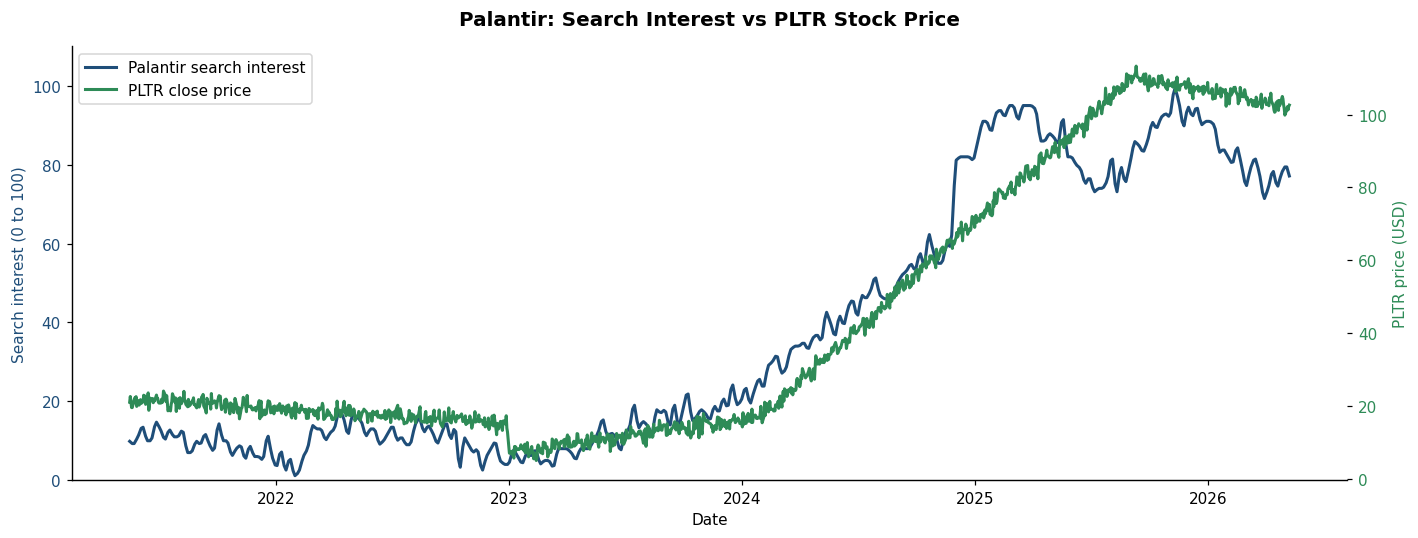

In [20]:
# Resample weekly search to daily so it aligns with daily stock prices
pltr_search_daily = trends['Palantir'].resample('D').interpolate()

combined = pd.DataFrame({
    'Search': pltr_search_daily,
    'Price': stock['Close'],
}).dropna()

fig, ax1 = plt.subplots(figsize=(13, 5))

color_search = '#1f4e79'
color_price = '#2e8b57'

ax1.plot(combined.index, combined['Search'], color=color_search,
         linewidth=2.0, label='Palantir search interest')
ax1.set_ylabel('Search interest (0 to 100)', fontsize=10, color=color_search)
ax1.tick_params(axis='y', labelcolor=color_search)
ax1.set_xlabel('Date', fontsize=10)
ax1.set_ylim(0, 110)

ax2 = ax1.twinx()
ax2.spines['top'].set_visible(False)
ax2.plot(combined.index, combined['Price'], color=color_price,
         linewidth=2.0, label='PLTR close price')
ax2.set_ylabel('PLTR price (USD)', fontsize=10, color=color_price)
ax2.tick_params(axis='y', labelcolor=color_price)

ax1.set_title('Palantir: Search Interest vs PLTR Stock Price',
              fontsize=13, fontweight='bold', pad=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

In [21]:
combined.corr().round(3)

,Search,Price
Search,1.000,0.954
Price,0.954,1.000
